Healthcare providers lose revenue and reduce care quality when patients miss scheduled appointments.
The goal of this project is to predict whether a patient will miss an appointment and explain the drivers behind that prediction so clinics can take preventive action.

## Phase 1 - Data and Model Foundation 
1. Reload the raw dataset
2. Map the target (no_show)
3. Remove leaky or useless features
4. Results: model ready, explainability safe features
5. Metrics and thresholding

In [2]:
import pandas as pd
import numpy as np


pd.__version__, np.__version__

('2.3.3', '2.2.6')

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [4]:
import pandas as pd

# reload the raw data
df = pd.read_csv("../data/raw/appointmentData.csv")
# load cleaned data 
# df = pd.read_csv("../data/appointments_clean_mapped.csv") 

In [5]:
df.head(5)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [6]:
# clean and map the target 
df['No-show'] = (
    df['No-show']
    .astype(str)
    .str.strip()
    .str.lower()
    .map({'yes': 1, 'no': 0})
)

print(df['No-show'].value_counts(dropna=False))

No-show
0    88208
1    22319
Name: count, dtype: int64


In [7]:
# drop any unmapped rows 
df = df.dropna(subset=['No-show'])
df['No-show'] = df['No-show'].astype(int)

In [8]:
# re-save the cleaned data 
df.to_csv("../data/appointments_clean_mapped.csv", index=False)

In [9]:
# check the data 
print(df.shape)
print(df["No-show"].value_counts())
print("NaNs in target:", df["No-show"].isna().sum())

(110527, 14)
No-show
0    88208
1    22319
Name: count, dtype: int64
NaNs in target: 0


In [10]:
import pandas as pd

# 1) Parse datetimes
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"], utc=True, errors="coerce")
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"], utc=True, errors="coerce")

# 2) Feature engineering
df["lead_time_days"] = (df["AppointmentDay"] - df["ScheduledDay"]).dt.total_seconds() / (24 * 3600)
df["scheduled_hour"] = df["ScheduledDay"].dt.hour
df["scheduled_dow"] = df["ScheduledDay"].dt.dayofweek
df["appointment_dow"] = df["AppointmentDay"].dt.dayofweek
df["appointment_is_weekend"] = (df["appointment_dow"] >= 5).astype(int)

# 3) Drop raw datetime + ID columns (prevent leakage + useless high-cardinality)
df = df.drop(columns=["ScheduledDay", "AppointmentDay", "PatientId", "AppointmentID"], errors="ignore")

In [11]:
# Full pipeline 
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# # feature / target split 
X = df.drop(columns=["No-show"])
y = df["No-show"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Column types
numeric_features = X.select_dtypes(include=["number", "bool"]).columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns

# Preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop"
)

# Model
log_reg = LogisticRegression(max_iter=2000)

# Logistic Regression - baseline model (Primary Explainability Model)
clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", log_reg)
])

clf.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
# evaluate 
from sklearn.metrics import classification_report, roc_auc_score

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba)) # show = 0 no show = 1 

              precision    recall  f1-score   support

           0       0.80      0.99      0.89     17642
           1       0.35      0.02      0.03      4464

    accuracy                           0.80     22106
   macro avg       0.58      0.50      0.46     22106
weighted avg       0.71      0.80      0.71     22106

ROC-AUC: 0.6682373637222838


Precision is decent (0.55)

Recall is terrible (0.03)

F1 is very low.

In [13]:
# generate recall across thresholds 
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.55, 0.05)

rows = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t)
    })

threshold_df = pd.DataFrame(rows)
threshold_df # use the table to find the lowest threshold that achieves recall ≥ 0.60

,threshold,precision,recall,f1
0,0.05,0.201936,1.000000,0.336018
1,0.10,0.209789,0.982303,0.345738
2,0.15,0.250588,0.834677,0.385455
3,0.20,0.306461,0.608871,0.407710
4,0.25,0.337402,0.396281,0.364479
5,0.30,0.352250,0.241935,0.286853
6,0.35,0.357455,0.128360,0.188891
7,0.40,0.339646,0.060260,0.102359
8,0.45,0.357527,0.029794,0.055004
9,0.50,0.354680,0.016129,0.030855


In [14]:
# re evaluate at chosen threshold 
chosen_threshold = 0.05

y_pred_adj = (y_proba >= chosen_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_adj))
confusion_matrix(y_test, y_pred_adj)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     17642
           1       0.20      1.00      0.34      4464

    accuracy                           0.20     22106
   macro avg       0.10      0.50      0.17     22106
weighted avg       0.04      0.20      0.07     22106



/Users/kalibraun/opt/anaconda3/envs/appointment-ml/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kalibraun/opt/anaconda3/envs/appointment-ml/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kalibraun/opt/anaconda3/envs/appointment-ml/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

array([[    0, 17642],
       [    0,  4464]])

In [15]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, (y_proba >= 0.05).astype(int))

array([[    0, 17642],
       [    0,  4464]])

At a threshold of 0.05, the model achieves near-perfect recall for no-shows, ensuring almost all missed appointments are identified. While precision is low at this threshold, it may be appropriate for low-cost, automated interventions where the cost of a false positive is minimal.

In [16]:
# lock in final threshold 
MODEL_THRESHOLD = 0.05

y_pred_final = (y_proba >= MODEL_THRESHOLD).astype(int)

The classification threshold was set to 0.05 to prioritize recall for no-shows. At this operating point, the model captures nearly all missed appointments, making it suitable for low-cost, automated interventions such as reminder messages or waitlist activation. While precision is lower at this threshold, the tradeoff is acceptable given the higher cost of missed appointments relative to false alerts.

## Phase 2 — Global Explainability

What globally increases or decreases no-show risk?
1. Fix pipeline so features are clean
2. Coefficent analysis
3. Results: a locked in model, threshold, clean features

In [17]:
# Extract Human-Readable Feature Names from the Pipeline
# start by accessing the preprocessing step 
preprocess = clf.named_steps["preprocess"]

# get numeric feature names 
numeric_features = preprocess.transformers_[0][2]
numeric_features

Index(['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism',
       'Handcap', 'SMS_received', 'lead_time_days', 'scheduled_hour',
       'scheduled_dow', 'appointment_dow', 'appointment_is_weekend'],
      dtype='object')

In [18]:
# get one hot encoded categorical features 
cat_transformer = preprocess.transformers_[1][1]
categorical_features = preprocess.transformers_[1][2]

cat_feature_names = cat_transformer.get_feature_names_out(categorical_features)
cat_feature_names[:10]

array(['Gender_F', 'Gender_M', 'Neighbourhood_AEROPORTO',
       'Neighbourhood_ANDORINHAS', 'Neighbourhood_ANTÔNIO HONÓRIO',
       'Neighbourhood_ARIOVALDO FAVALESSA',
       'Neighbourhood_BARRO VERMELHO', 'Neighbourhood_BELA VISTA',
       'Neighbourhood_BENTO FERREIRA', 'Neighbourhood_BOA VISTA'],
      dtype=object)

In [19]:
# combine into a single list 
feature_names = list(numeric_features) + list(cat_feature_names)

len(feature_names)

95

In [20]:
assert "lead_time_days" in feature_names
assert not any("ScheduledDay_" in f for f in feature_names)

In [21]:
clf.named_steps["model"].coef_[0].shape[0] == len(feature_names)

True

In [22]:
# Extract Logistic Regression Coefficients
import pandas as pd
import numpy as np

coefs = clf.named_steps["model"].coef_[0]

coef_df = (
    pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs
    })
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
)

coef_df.head(15)

,feature,coefficient,abs_coef
13,Gender_M,-0.477995,0.477995
12,Gender_F,-0.452685,0.452685
84,Neighbourhood_SANTOS DUMONT,0.428214,0.428214
87,Neighbourhood_SOLON BORGES,-0.421856,0.421856
52,Neighbourhood_JARDIM CAMBURI,-0.393592,0.393592
7,lead_time_days,0.379245,0.379245
76,Neighbourhood_SANTA CLARA,0.372558,0.372558
51,Neighbourhood_JABOUR,-0.353793,0.353793
66,Neighbourhood_PARQUE MOSCOSO,0.334872,0.334872
30,Neighbourhood_DE LOURDES,-0.325171,0.325171


* Positive coefficient → increases no-show risk
* Negative coefficient → decreases no-show risk
* Larger magnitude → stronger effect

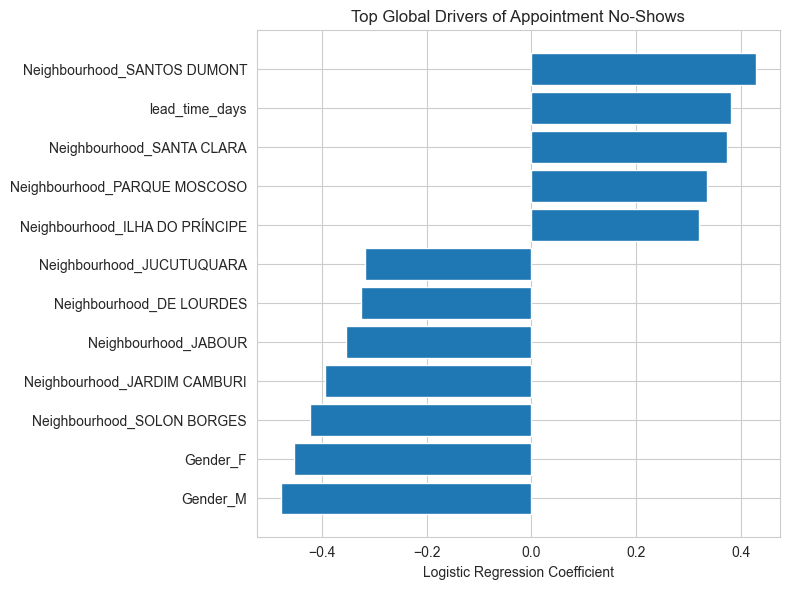

In [23]:
# visualize the top drivers 
import matplotlib.pyplot as plt

top = coef_df.head(12).sort_values("coefficient")

plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["coefficient"])
plt.title("Top Global Drivers of Appointment No-Shows")
plt.xlabel("Logistic Regression Coefficient")
plt.tight_layout()
plt.show()

In [24]:
coef_df[coef_df["feature"].str.startswith("Neighbourhood_")].head(10)

,feature,coefficient,abs_coef
84,Neighbourhood_SANTOS DUMONT,0.428214,0.428214
87,Neighbourhood_SOLON BORGES,-0.421856,0.421856
52,Neighbourhood_JARDIM CAMBURI,-0.393592,0.393592
76,Neighbourhood_SANTA CLARA,0.372558,0.372558
51,Neighbourhood_JABOUR,-0.353793,0.353793
66,Neighbourhood_PARQUE MOSCOSO,0.334872,0.334872
30,Neighbourhood_DE LOURDES,-0.325171,0.325171
47,Neighbourhood_ILHA DO PRÍNCIPE,0.319443,0.319443
56,Neighbourhood_JUCUTUQUARA,-0.316899,0.316899
31,Neighbourhood_DO CABRAL,-0.308937,0.308937


Geographic variation shows measurable differences in no-show risk, potentially reflecting access, transportation, or socioeconomic factors.

lead_time_days is the strongest non neighbourhood feature - longer delays between scheduling and the appointment date are associated with a higher likelihood of no-shows, suggesting that appointments booked far in advance are more likely to be missed.

Gender indicators appear among the top coefficients; however, because both categories are encoded relative to the model intercept, these effects should be interpreted cautiously and not as a direct comparison between genders.

Global explainability analysis using logistic regression coefficients shows that appointment lead time is one of the strongest drivers of no-show risk, with longer delays increasing the likelihood of missed appointments. Geographic variation also plays a role, with certain neighborhoods exhibiting consistently higher or lower risk relative to the baseline. Gender indicators appear among the top coefficients; however, these effects should be interpreted cautiously, as both categories are encoded relative to the model intercept rather than directly compared. Overall, the results highlight the importance of scheduling dynamics and contextual factors in predicting appointment adherence.

## Phase 3: SHAP

In [25]:
# generate SHAP global plot - explains patterns across everyone 
import shap

# Grab preprocess + model from  pipeline
preprocess = clf.named_steps["preprocess"]
model = clf.named_steps["model"]

# Transform train + test into the model’s feature space
X_train_trans = preprocess.transform(X_train)
X_test_trans  = preprocess.transform(X_test)

# (Optional) if matrices are sparse, convert for SHAP compatibility in some environments
try:
    X_train_trans_dense = X_train_trans.toarray()
    X_test_trans_dense = X_test_trans.toarray()
except AttributeError:
    X_train_trans_dense = X_train_trans
    X_test_trans_dense = X_test_trans


In [26]:
# use a sample for speed
rng = np.random.default_rng(42)
n = min(5000, X_train_trans_dense.shape[0])
idx = rng.choice(X_train_trans_dense.shape[0], size=n, replace=False)

X_shap = X_train_trans_dense[idx]

In [27]:
# build SHAP explainer for linear regression 
explainer = shap.LinearExplainer(model, X_shap)
shap_values = explainer.shap_values(X_shap)

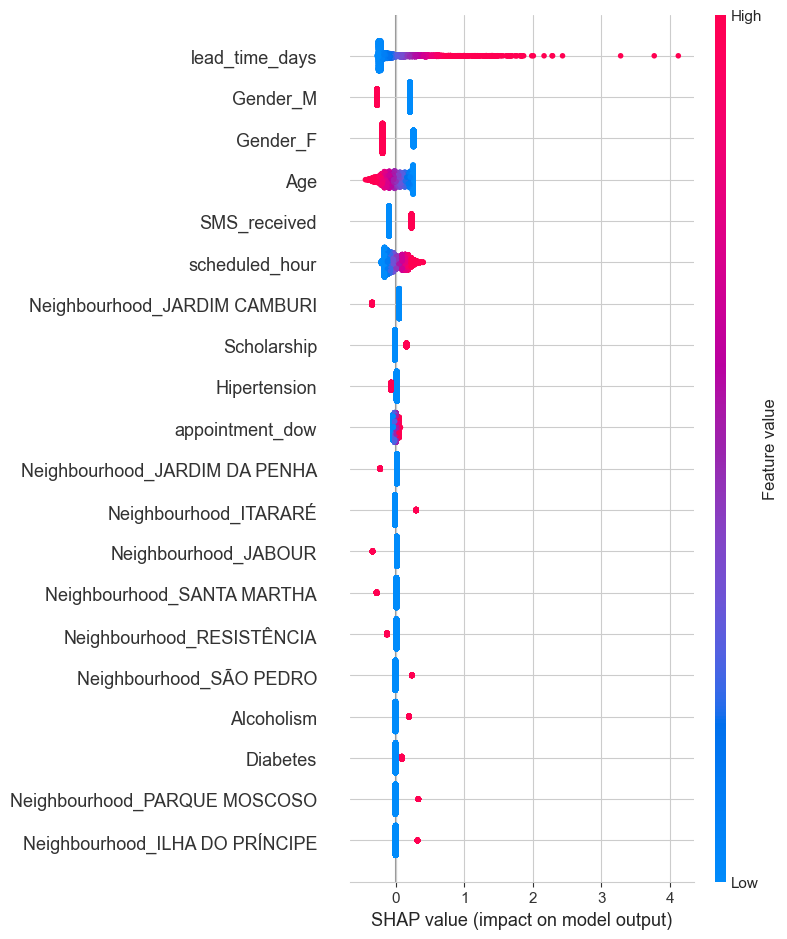

In [28]:
# SHAP global summary plot 
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    max_display=20
)

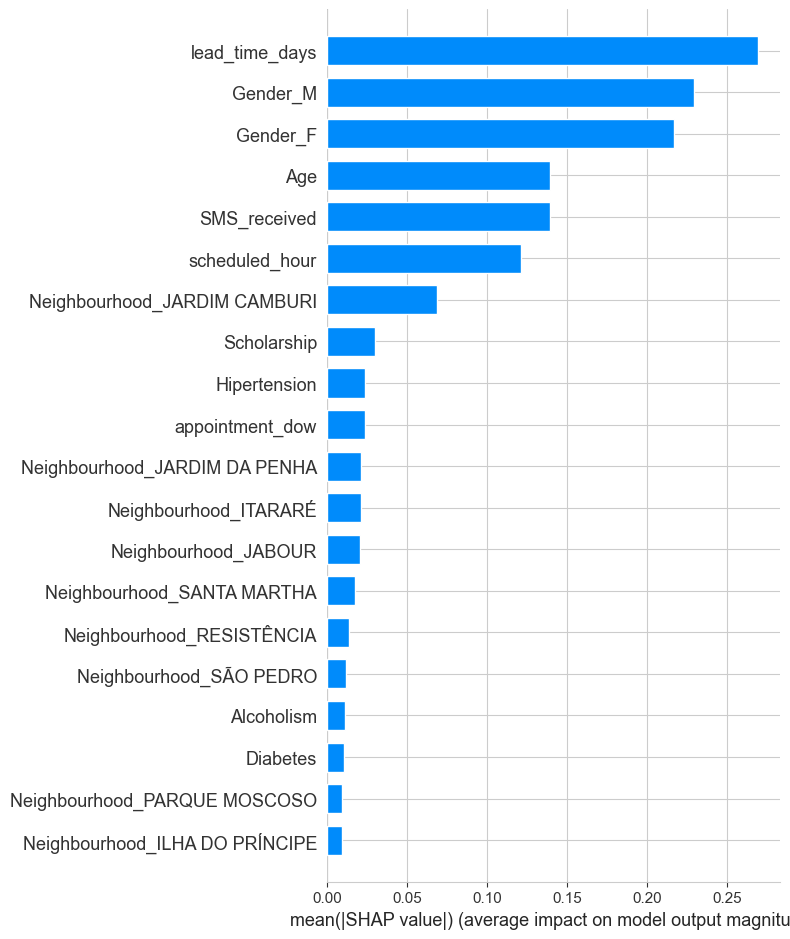

In [29]:
# SHAP global importance 
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20
)

In [30]:
# Compute mean absolute SHAP value per feature
shap_importance = np.abs(shap_values).mean(axis=0)

shap_df = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": shap_importance
    })
    .sort_values("mean_abs_shap", ascending=False)
)

# Top 10 features - which features move the predicition most (on avg) 
shap_df.head(10)

,feature,mean_abs_shap
7,lead_time_days,0.269620
13,Gender_M,0.229187
12,Gender_F,0.217052
0,Age,0.139283
6,SMS_received,0.139208
8,scheduled_hour,0.121124
52,Neighbourhood_JARDIM CAMBURI,0.069008
1,Scholarship,0.029825
2,Hipertension,0.024024
10,appointment_dow,0.023910


Global explainability analysis using SHAP values shows that appointment lead time is the strongest driver of no-show risk, with longer delays consistently increasing risk across the population. Demographic factors such as age and gender also contribute meaningfully to model predictions, though these effects should be interpreted cautiously and not as causal. Operational factors, including whether an SMS reminder was received and the scheduled hour of the appointment, further influence adherence, highlighting opportunities for targeted, low-cost interventions. Geographic and health-related features have smaller but measurable effects, suggesting that no-show behavior is driven primarily by scheduling dynamics rather than clinical factors.

In [32]:
# local explainability, going to explain individual decisions in a way a clinic could actually understand
# create predicition frame 
MODEL_THRESHOLD = 0.05

pred_df = X_test.copy()
pred_df["y_true"] = y_test.values
pred_df["y_proba"] = y_proba
pred_df["y_pred"] = (y_proba >= MODEL_THRESHOLD).astype(int)

In [33]:
# pick one true post
tp_idx = pred_df[
    (pred_df["y_true"] == 1) &
    (pred_df["y_pred"] == 1)
].sort_values("y_proba", ascending=False).index[0]

tp_idx

np.int64(102795)

In [34]:
# pick one false pos
fp_idx = pred_df[
    (pred_df["y_true"] == 0) &
    (pred_df["y_pred"] == 1)
].sort_values("y_proba", ascending=False).index[0]

fp_idx

np.int64(27585)

In [35]:
# generate SHAP values for individual rows, reuse global explainer 

# Transform the specific rows
tp_trans = preprocess.transform(X_test.loc[[tp_idx]])
fp_trans = preprocess.transform(X_test.loc[[fp_idx]])

# Convert to dense if needed
try:
    tp_trans = tp_trans.toarray()
    fp_trans = fp_trans.toarray()
except AttributeError:
    pass

# SHAP values
tp_shap = explainer.shap_values(tp_trans)
fp_shap = explainer.shap_values(fp_trans)

# Handle list output if needed
if isinstance(tp_shap, list):
    tp_shap = tp_shap[0]
    fp_shap = fp_shap[0]


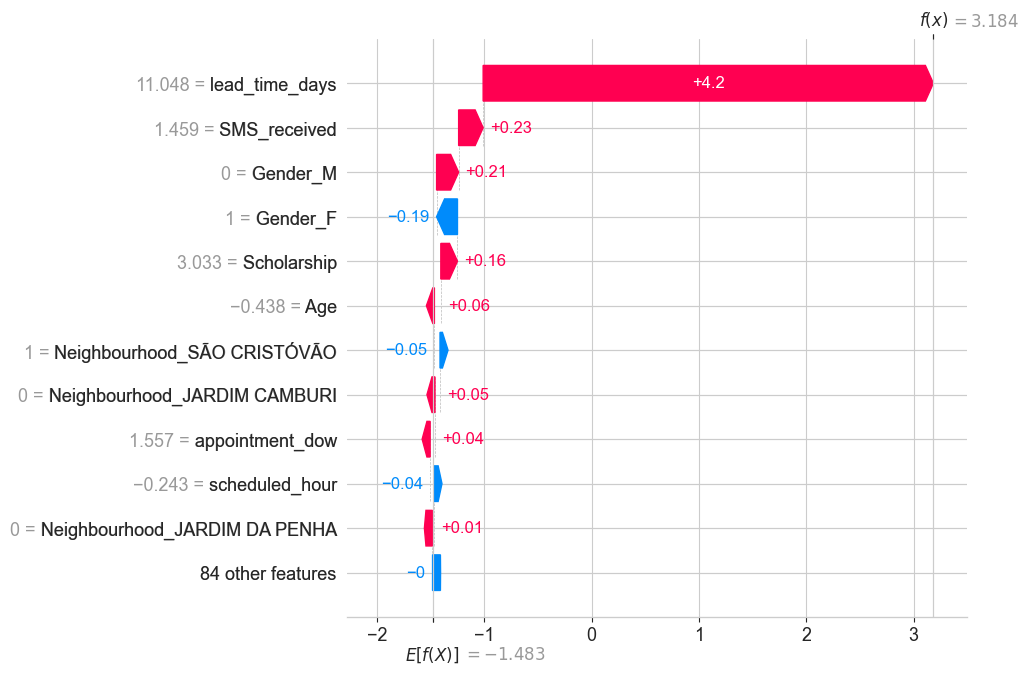

In [36]:
# SHAP waterfall plots - true positive actual no show
shap.plots.waterfall(
    shap.Explanation(
        values=tp_shap[0],
        base_values=explainer.expected_value,
        data=tp_trans[0],
        feature_names=feature_names
    ),
    max_display=12
)

This appointment was flagged as high risk primarily due to a long delay between scheduling and the appointment date, combined with the absence of an SMS reminder. These factors outweighed protective signals, resulting in a predicted no-show risk above the intervention threshold.

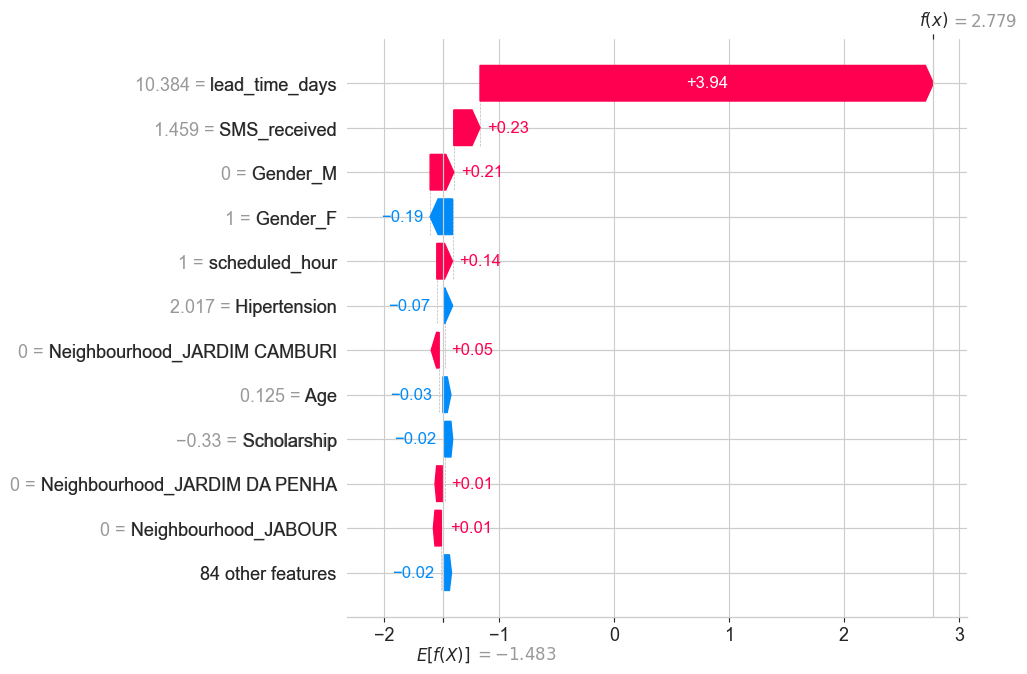

In [37]:
# false positive, flagged but showed
shap.plots.waterfall(
    shap.Explanation(
        values=fp_shap[0],
        base_values=explainer.expected_value,
        data=fp_trans[0],
        feature_names=feature_names
    ),
    max_display=12
)

Although this patient ultimately attended the appointment, the model flagged the visit as high risk due to factors commonly associated with no-shows. This illustrates the tradeoff of a recall-focused threshold, where some false positives are expected in order to minimize missed appointments.